# 12a — Validation Evaluation

This notebook performs Week 6 validation using the **saved fitted Week 5 tuned pipelines**.

### Week 5 consistency requirements enforced
- The fitted `.joblib` pipelines are loaded directly from `models/`.
- The notebook does **not** rebuild, refit, or retune Week 5 models.
- The pipeline structure is read from each saved pipeline rather than hardcoded.
- The saved Week 5 preprocessing, `VarianceThreshold`, `SelectKBest`, classifier, and tuned settings are therefore reused exactly as stored.
- XGBoost is evaluated through the saved fitted XGBoost pipeline.
- Held-out validation data are used only for `predict()` and `predict_proba()`.
- Both predicted classes and predicted probabilities are saved for later Week 6 calibration, ROC/PR, SHAP, and error-analysis tasks.
- The exact task-aware Week 5 validation CSVs are used.
- An artifact audit records the actual pipeline steps loaded from each `.joblib` model.

### Required outputs
- `outputs/metrics/validation_results.csv`
- `outputs/metrics/validation_predictions.csv`
- `outputs/metrics/validation_probabilities.csv`
- validation confusion matrices
- `outputs/tables/validation_comparison.csv`
- `outputs/tables/validation_best_models.csv`
- `outputs/tables/week5_pipeline_exactness_audit.csv`
- `outputs/figures/validation_model_comparison.png`

> The purpose of this notebook is validation, not retuning. No Week 5 hyperparameter is re-estimated from the validation set.


## 1. Setup


In [1]:
from pathlib import Path
import os
import re
import sys
import warnings

# Prevent the VS Code/Jupyter backend setting from breaking imports.
os.environ.pop("MPLBACKEND", None)

import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

cwd = Path.cwd().resolve()

if (cwd / "src").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Run this notebook from the project repository or notebooks folder."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
METRICS_DIR = OUTPUTS_DIR / "metrics"
TABLES_DIR = OUTPUTS_DIR / "tables"
FIGURES_DIR = OUTPUTS_DIR / "figures"

for folder in [METRICS_DIR, TABLES_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

TARGET = "label"
ID_COLUMN = "patient_id"

print("Python:", sys.executable)
print("Project root:", PROJECT_ROOT)
print("Week 5 model directory:", MODELS_DIR)
print("Validation mode: load saved fitted Week 5 pipelines; no refitting")


Python: c:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\.venv\Scripts\python.exe
Project root: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease
Week 5 model directory: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\models
Validation mode: load saved fitted Week 5 pipelines; no refitting


## 2. Load the saved Week 5 tuned models

The validation notebook now uses the fitted Week 5 `.joblib` artifacts directly.

This avoids reconstructing the Week 5 pipeline in 12a. The preprocessing, variance filtering, feature selection, tuned classifier settings, and pipeline order are all taken from the fitted pipeline that was actually saved in Week 5.


In [2]:
model_files = sorted(MODELS_DIR.glob("*.joblib"))

if not model_files:
    raise FileNotFoundError(
        f"No .joblib models were found in: {MODELS_DIR}"
    )

print(f"Found {len(model_files)} saved model artifact(s):")
for path in model_files:
    print(" -", path.name)


Found 9 saved model artifact(s):
 - demographics_plus_questionnaire_logistic_regression.joblib
 - demographics_plus_questionnaire_random_forest.joblib
 - demographics_plus_questionnaire_xgboost.joblib
 - full_multimodal_logistic_regression.joblib
 - full_multimodal_random_forest.joblib
 - full_multimodal_xgboost.joblib
 - wearable_plus_questionnaire_logistic_regression.joblib
 - wearable_plus_questionnaire_random_forest.joblib
 - wearable_plus_questionnaire_xgboost.joblib


## 3. Build the tuned-model table

The model inventory is built directly from the saved Week 5 model filenames.

If both an older `multimodal_*` artifact and a newer `full_multimodal_*` artifact are present, the current `full_multimodal_*` artifact is preferred. Otherwise, the newest matching saved model is selected.

The final inventory should contain the nine Week 5 candidates:

- Logistic Regression
- Random Forest
- XGBoost

for each of:

- Demographics + Questionnaire
- Wearable + Questionnaire
- Full Multimodal


In [3]:
def clean_text(value):
    return re.sub(
        r"[^a-z0-9]+",
        "_",
        str(value).strip().lower(),
    ).strip("_")


MODEL_SUFFIXES = {
    "logistic_regression": "Logistic Regression",
    "random_forest": "Random Forest",
    "xgboost": "XGBoost",
}

DATASET_PREFIXES = {
    "demographics_plus_questionnaire": "Demographics + Questionnaire",
    "wearable_plus_questionnaire": "Wearable + Questionnaire",
    "multimodal": "Full Multimodal",
    "full_multimodal": "Full Multimodal",
}

records = []

for path in model_files:
    stem = clean_text(path.stem)

    for suffix, model_name in MODEL_SUFFIXES.items():
        if not stem.endswith(suffix):
            continue

        dataset_key = stem[: -(len(suffix) + 1)]
        dataset_name = DATASET_PREFIXES.get(dataset_key)

        if dataset_name:
            records.append({
                "dataset": dataset_name,
                "model": model_name,
                "filename": path.name,
                "model_path": path,
                "modified_time": path.stat().st_mtime,
                "preferred_name": int(dataset_key == "full_multimodal"),
            })
        break

model_inventory = pd.DataFrame(records)

if model_inventory.empty:
    raise RuntimeError("No recognized Week 5 model artifacts were found.")

model_inventory = (
    model_inventory
    .sort_values(
        ["dataset", "model", "preferred_name", "modified_time"],
        ascending=[True, True, False, False],
    )
    .drop_duplicates(
        subset=["dataset", "model"],
        keep="first",
    )
    .sort_values(["dataset", "model"])
    .reset_index(drop=True)
)

display(
    model_inventory[
        ["dataset", "model", "filename"]
    ]
)

print("Models selected for validation:", len(model_inventory))


,dataset,model,filename
0,Demographics + Questionnaire,Logistic Regression,demographics_plus_questionnaire_logistic_regre...
1,Demographics + Questionnaire,Random Forest,demographics_plus_questionnaire_random_forest....
2,Demographics + Questionnaire,XGBoost,demographics_plus_questionnaire_xgboost.joblib
3,Full Multimodal,Logistic Regression,full_multimodal_logistic_regression.joblib
4,Full Multimodal,Random Forest,full_multimodal_random_forest.joblib
5,Full Multimodal,XGBoost,full_multimodal_xgboost.joblib
6,Wearable + Questionnaire,Logistic Regression,wearable_plus_questionnaire_logistic_regressio...
7,Wearable + Questionnaire,Random Forest,wearable_plus_questionnaire_random_forest.joblib
8,Wearable + Questionnaire,XGBoost,wearable_plus_questionnaire_xgboost.joblib


Models selected for validation: 9


## 4. Find the training and validation datasets

Validation uses the exact held-out task-aware Week 5 validation datasets.

The training datasets are listed only for schema verification. They are **not** used to refit the saved pipelines in this notebook.


In [4]:
DATA_FILES = {
    "Demographics + Questionnaire": {
        "train":
            DATA_DIR / "processed"
            / "train_demographics_questionnaire_task_aware.csv",
        "validation":
            DATA_DIR / "processed"
            / "validation_demographics_questionnaire_task_aware.csv",
    },
    "Wearable + Questionnaire": {
        "train":
            DATA_DIR / "processed"
            / "train_wearable_questionnaire_task_aware.csv",
        "validation":
            DATA_DIR / "processed"
            / "validation_wearable_questionnaire_task_aware.csv",
    },
    "Full Multimodal": {
        "train":
            DATA_DIR / "processed"
            / "train_multimodal_full_task_aware.csv",
        "validation":
            DATA_DIR / "processed"
            / "validation_multimodal_full_task_aware.csv",
    },
}

data_rows = []

for dataset, paths in DATA_FILES.items():
    train_exists = paths["train"].exists()
    validation_exists = paths["validation"].exists()

    train_cols = (
        len(pd.read_csv(paths["train"], nrows=1).columns)
        if train_exists else None
    )
    validation_cols = (
        len(pd.read_csv(paths["validation"], nrows=1).columns)
        if validation_exists else None
    )

    data_rows.append({
        "dataset": dataset,
        "train_file": paths["train"].name,
        "train_exists": train_exists,
        "train_columns": train_cols,
        "validation_file": paths["validation"].name,
        "validation_exists": validation_exists,
        "validation_columns": validation_cols,
    })

data_inventory = pd.DataFrame(data_rows)
display(data_inventory)

if not data_inventory["validation_exists"].all():
    raise FileNotFoundError(
        "One or more required Week 5 validation datasets are missing."
    )


,dataset,train_file,train_exists,train_columns,validation_file,validation_exists,validation_columns
0,Demographics + Questionnaire,train_demographics_questionnaire_task_aware.csv,True,59,validation_demographics_questionnaire_task_awa...,True,59
1,Wearable + Questionnaire,train_wearable_questionnaire_task_aware.csv,True,2403,validation_wearable_questionnaire_task_aware.csv,True,2403
2,Full Multimodal,train_multimodal_full_task_aware.csv,True,2413,validation_multimodal_full_task_aware.csv,True,2413


## 5. Restore the Week 5 tuned pipeline exactly

Rather than recreating the pipeline in this notebook, 12a loads the **actual fitted Week 5 pipeline** from each `.joblib` artifact.

This means the pipeline definition is not hardcoded in validation. The notebook inspects each loaded artifact and records its real pipeline steps.

For the current Week 5 artifacts, this should preserve the fitted sequence that includes preprocessing, zero-variance filtering, feature selection, and the tuned classifier.

No call to `.fit()` is made in this notebook.


In [5]:
def get_pipeline_metadata(pipeline):
    if hasattr(pipeline, "steps"):
        pipeline_steps = [name for name, _ in pipeline.steps]
    else:
        pipeline_steps = [type(pipeline).__name__]

    variance_threshold = None
    feature_selection_k = None
    classifier_class = type(pipeline).__name__

    if hasattr(pipeline, "named_steps"):
        named_steps = pipeline.named_steps

        variance_step = named_steps.get("variance_filter")
        if variance_step is not None:
            variance_threshold = getattr(
                variance_step,
                "threshold",
                None,
            )

        feature_step = named_steps.get("feature_selection")
        if feature_step is not None:
            feature_selection_k = getattr(
                feature_step,
                "k",
                None,
            )

        classifier = named_steps.get("classifier")
        if classifier is not None:
            classifier_class = type(classifier).__name__

    return {
        "pipeline_steps": " -> ".join(pipeline_steps),
        "variance_threshold": variance_threshold,
        "feature_selection__k": feature_selection_k,
        "classifier_class": classifier_class,
    }


pipeline_inventory_rows = []

for _, row in model_inventory.iterrows():
    pipeline = joblib.load(row["model_path"])
    metadata = get_pipeline_metadata(pipeline)

    pipeline_inventory_rows.append({
        "dataset": row["dataset"],
        "model": row["model"],
        "filename": row["filename"],
        **metadata,
    })

pipeline_inventory = pd.DataFrame(pipeline_inventory_rows)
display(pipeline_inventory)


,dataset,model,filename,pipeline_steps,variance_threshold,feature_selection__k,classifier_class
0,Demographics + Questionnaire,Logistic Regression,demographics_plus_questionnaire_logistic_regre...,preprocessing -> variance_filter -> feature_se...,0.0,all,LogisticRegression
1,Demographics + Questionnaire,Random Forest,demographics_plus_questionnaire_random_forest....,preprocessing -> variance_filter -> feature_se...,0.0,50,RandomForestClassifier
2,Demographics + Questionnaire,XGBoost,demographics_plus_questionnaire_xgboost.joblib,preprocessing -> variance_filter -> feature_se...,0.0,all,XGBClassifier
3,Full Multimodal,Logistic Regression,full_multimodal_logistic_regression.joblib,preprocessing -> variance_filter -> feature_se...,0.0,1000,LogisticRegression
4,Full Multimodal,Random Forest,full_multimodal_random_forest.joblib,preprocessing -> variance_filter -> feature_se...,0.0,50,RandomForestClassifier
5,Full Multimodal,XGBoost,full_multimodal_xgboost.joblib,preprocessing -> variance_filter -> feature_se...,0.0,1000,XGBClassifier
6,Wearable + Questionnaire,Logistic Regression,wearable_plus_questionnaire_logistic_regressio...,preprocessing -> variance_filter -> feature_se...,0.0,1000,LogisticRegression
7,Wearable + Questionnaire,Random Forest,wearable_plus_questionnaire_random_forest.joblib,preprocessing -> variance_filter -> feature_se...,0.0,50,RandomForestClassifier
8,Wearable + Questionnaire,XGBoost,wearable_plus_questionnaire_xgboost.joblib,preprocessing -> variance_filter -> feature_se...,0.0,1000,XGBClassifier


## 6. Evaluate saved Week 5 pipelines on held-out validation

For every Week 5 candidate:

1. the fitted `.joblib` pipeline is loaded;
2. the corresponding held-out validation CSV is loaded;
3. the raw validation columns are aligned to `pipeline.feature_names_in_`;
4. the saved fitted pipeline performs `predict()` and `predict_proba()`;
5. validation metrics, predictions, probabilities, confusion matrices, and pipeline audit information are recorded.

The validation data are never supplied to `.fit()`.

In [6]:
def calculate_validation_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "precision_macro": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "recall_macro": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
    }


ALLOWED_MISSING_FEATURES = {"urinary_count"}

results = []
prediction_store = {}
prediction_rows = []
probability_rows = []
week5_exactness_rows = []
failure_rows = []


for _, model_row in model_inventory.iterrows():
    dataset = model_row["dataset"]
    model_name = model_row["model"]
    model_path = Path(model_row["model_path"])
    validation_file = DATA_FILES[dataset]["validation"]

    print("\n" + "=" * 80)
    print(f"{dataset} | {model_name}")
    print("=" * 80)

    try:
        pipeline = joblib.load(model_path)

        validation_df = pd.read_csv(
            validation_file,
            dtype={ID_COLUMN: str},
        )

        if TARGET not in validation_df.columns:
            raise ValueError(
                f"{TARGET!r} is missing from validation data."
            )

        y_val = validation_df[TARGET].copy()

        if hasattr(pipeline, "feature_names_in_"):
            expected_columns = list(
                pipeline.feature_names_in_
            )
        else:
            expected_columns = [
                column
                for column in validation_df.columns
                if column not in {TARGET, ID_COLUMN}
            ]

        missing_columns = [
            column
            for column in expected_columns
            if column not in validation_df.columns
        ]

        unsupported_missing = [
            column
            for column in missing_columns
            if column not in ALLOWED_MISSING_FEATURES
        ]

        if unsupported_missing:
            raise ValueError(
                "Validation data are missing "
                f"{len(unsupported_missing)} unsupported feature(s): "
                f"{unsupported_missing[:10]}"
            )

        added_missing = []

        for column in missing_columns:
            validation_df[column] = np.nan
            added_missing.append(column)

        X_val = validation_df[
            expected_columns
        ].copy()

        print(
            f"Model expects: {len(expected_columns)} raw features"
        )
        print(
            f"Validation aligned: {X_val.shape[1]} raw features"
        )

        if added_missing:
            print(
                "Compatibility handling:",
                added_missing,
                "supplied as NaN",
            )

        # IMPORTANT: validation only. No fit() call.
        y_pred = pipeline.predict(X_val)

        metrics = calculate_validation_metrics(
            y_val,
            y_pred,
        )

        metadata = get_pipeline_metadata(
            pipeline
        )

        key = (
            f"{clean_text(dataset)}"
            f"__{clean_text(model_name)}"
        )

        prediction_store[key] = (
            y_val.copy(),
            y_pred.copy(),
        )

        results.append({
            "result_key": key,
            "dataset": dataset,
            "model": model_name,
            "artifact_filename": model_path.name,
            "validation_file": validation_file.name,
            "n_validation": len(y_val),
            "pipeline_steps": metadata["pipeline_steps"],
            "variance_threshold": metadata["variance_threshold"],
            "feature_selection__k": metadata["feature_selection__k"],
            "classifier_class": metadata["classifier_class"],
            "added_missing_features":
                ",".join(added_missing) if added_missing else "",
            **metrics,
        })

        participant_ids = (
            validation_df[ID_COLUMN].astype(str).values
            if ID_COLUMN in validation_df.columns
            else np.arange(len(validation_df)).astype(str)
        )

        for participant_id, true_label, predicted_label in zip(
            participant_ids,
            y_val,
            y_pred,
        ):
            prediction_rows.append({
                ID_COLUMN: participant_id,
                "dataset": dataset,
                "model": model_name,
                "true_label": true_label,
                "predicted_label": predicted_label,
            })

        if hasattr(pipeline, "predict_proba"):
            probabilities = pipeline.predict_proba(
                X_val
            )

            classes = getattr(
                pipeline,
                "classes_",
                None,
            )

            if classes is None and hasattr(
                pipeline,
                "named_steps",
            ):
                classifier = pipeline.named_steps.get(
                    "classifier"
                )
                classes = getattr(
                    classifier,
                    "classes_",
                    np.arange(probabilities.shape[1]),
                )

            if classes is None:
                classes = np.arange(
                    probabilities.shape[1]
                )

            for row_index, (
                participant_id,
                true_label,
            ) in enumerate(
                zip(
                    participant_ids,
                    y_val,
                )
            ):
                probability_row = {
                    ID_COLUMN: participant_id,
                    "dataset": dataset,
                    "model": model_name,
                    "true_label": true_label,
                }

                for class_index, class_label in enumerate(
                    classes
                ):
                    probability_row[
                        f"prob_class_{class_label}"
                    ] = probabilities[
                        row_index,
                        class_index,
                    ]

                probability_rows.append(
                    probability_row
                )

        else:
            print(
                "⚠ Saved pipeline does not expose predict_proba()."
            )

        week5_exactness_rows.append({
            "dataset": dataset,
            "model": model_name,
            "artifact_filename": model_path.name,
            "pipeline_steps": metadata["pipeline_steps"],
            "variance_threshold": metadata["variance_threshold"],
            "feature_selection__k": metadata["feature_selection__k"],
            "classifier_class": metadata["classifier_class"],
            "added_missing_features":
                ",".join(added_missing) if added_missing else "",
            "refit_in_validation": False,
            "status": "PASS",
        })

        print(
            f"✓ Validation successful | "
            f"Macro F1={metrics['macro_f1']:.4f}"
        )

    except Exception as exc:
        failure_rows.append({
            "dataset": dataset,
            "model": model_name,
            "artifact_filename": model_path.name,
            "error_type": type(exc).__name__,
            "error": str(exc),
        })

        week5_exactness_rows.append({
            "dataset": dataset,
            "model": model_name,
            "artifact_filename": model_path.name,
            "pipeline_steps": "",
            "variance_threshold": None,
            "feature_selection__k": None,
            "classifier_class": "",
            "added_missing_features": "",
            "refit_in_validation": False,
            "status": "FAIL",
        })

        print(
            f"✗ {type(exc).__name__}: {exc}"
        )


validation_results = pd.DataFrame(results)
validation_predictions = pd.DataFrame(prediction_rows)
validation_probabilities = pd.DataFrame(probability_rows)
week5_pipeline_exactness_audit = pd.DataFrame(
    week5_exactness_rows
)
validation_failures = pd.DataFrame(failure_rows)

if validation_results.empty:
    raise RuntimeError(
        "No saved Week 5 pipeline completed validation successfully. "
        "Review the model-level errors above."
    )

validation_results = (
    validation_results
    .sort_values(
        ["macro_f1", "balanced_accuracy"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

validation_results.insert(
    0,
    "rank",
    np.arange(1, len(validation_results) + 1),
)

print(
    "\nSuccessful Week 5 pipelines evaluated:",
    len(validation_results),
)

display(validation_results)



Demographics + Questionnaire | Logistic Regression
Model expects: 52 raw features
Validation aligned: 52 raw features
✓ Validation successful | Macro F1=0.6329

Demographics + Questionnaire | Random Forest
Model expects: 52 raw features
Validation aligned: 52 raw features
✓ Validation successful | Macro F1=0.5833

Demographics + Questionnaire | XGBoost
Model expects: 52 raw features
Validation aligned: 52 raw features
✓ Validation successful | Macro F1=0.5554

Full Multimodal | Logistic Regression
Model expects: 2406 raw features
Validation aligned: 2406 raw features
✓ Validation successful | Macro F1=0.6841

Full Multimodal | Random Forest
Model expects: 2406 raw features
Validation aligned: 2406 raw features
✓ Validation successful | Macro F1=0.7826

Full Multimodal | XGBoost
Model expects: 2406 raw features
Validation aligned: 2406 raw features
✓ Validation successful | Macro F1=0.7367

Wearable + Questionnaire | Logistic Regression
Model expects: 2398 raw features
Validation align

,rank,result_key,dataset,model,artifact_filename,validation_file,n_validation,pipeline_steps,variance_threshold,feature_selection__k,classifier_class,added_missing_features,accuracy,balanced_accuracy,macro_f1,precision_macro,recall_macro
0,1,full_multimodal__random_forest,Full Multimodal,Random Forest,full_multimodal_random_forest.joblib,validation_multimodal_full_task_aware.csv,70,preprocessing -> variance_filter -> feature_se...,0.0,50,RandomForestClassifier,,0.814286,0.813965,0.782582,0.772535,0.813965
1,2,full_multimodal__xgboost,Full Multimodal,XGBoost,full_multimodal_xgboost.joblib,validation_multimodal_full_task_aware.csv,70,preprocessing -> variance_filter -> feature_se...,0.0,1000,XGBClassifier,,0.771429,0.719154,0.736732,0.764366,0.719154
2,3,wearable_questionnaire__random_forest,Wearable + Questionnaire,Random Forest,wearable_plus_questionnaire_random_forest.joblib,validation_wearable_questionnaire_task_aware.csv,70,preprocessing -> variance_filter -> feature_se...,0.0,50,RandomForestClassifier,,0.771429,0.758449,0.735289,0.726786,0.758449
3,4,wearable_questionnaire__xgboost,Wearable + Questionnaire,XGBoost,wearable_plus_questionnaire_xgboost.joblib,validation_wearable_questionnaire_task_aware.csv,70,preprocessing -> variance_filter -> feature_se...,0.0,1000,XGBClassifier,,0.757143,0.699546,0.717505,0.750269,0.699546
4,5,full_multimodal__logistic_regression,Full Multimodal,Logistic Regression,full_multimodal_logistic_regression.joblib,validation_multimodal_full_task_aware.csv,70,preprocessing -> variance_filter -> feature_se...,0.0,1000,LogisticRegression,,0.728571,0.678423,0.684118,0.694608,0.678423
5,6,wearable_questionnaire__logistic_regression,Wearable + Questionnaire,Logistic Regression,wearable_plus_questionnaire_logistic_regressio...,validation_wearable_questionnaire_task_aware.csv,70,preprocessing -> variance_filter -> feature_se...,0.0,1000,LogisticRegression,,0.728571,0.678423,0.684118,0.694608,0.678423
6,7,demographics_questionnaire__logistic_regression,Demographics + Questionnaire,Logistic Regression,demographics_plus_questionnaire_logistic_regre...,validation_demographics_questionnaire_task_awa...,70,preprocessing -> variance_filter -> feature_se...,0.0,all,LogisticRegression,,0.657143,0.701578,0.632898,0.618251,0.701578
7,8,demographics_questionnaire__random_forest,Demographics + Questionnaire,Random Forest,demographics_plus_questionnaire_random_forest....,validation_demographics_questionnaire_task_awa...,70,preprocessing -> variance_filter -> feature_se...,0.0,50,RandomForestClassifier,,0.642857,0.619719,0.583333,0.569801,0.619719
8,9,demographics_questionnaire__xgboost,Demographics + Questionnaire,XGBoost,demographics_plus_questionnaire_xgboost.joblib,validation_demographics_questionnaire_task_awa...,70,preprocessing -> variance_filter -> feature_se...,0.0,all,XGBClassifier,,0.657143,0.557429,0.555382,0.570833,0.557429


## 7. Save `validation_results.csv` and comparison table


In [7]:
validation_results.to_csv(
    METRICS_DIR / "validation_results.csv",
    index=False,
)

validation_predictions.to_csv(
    METRICS_DIR / "validation_predictions.csv",
    index=False,
)

validation_probabilities.to_csv(
    METRICS_DIR / "validation_probabilities.csv",
    index=False,
)

week5_pipeline_exactness_audit.to_csv(
    TABLES_DIR / "week5_pipeline_exactness_audit.csv",
    index=False,
)

comparison_cols = [
    "rank",
    "dataset",
    "model",
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "precision_macro",
    "recall_macro",
    "artifact_filename",
]

validation_comparison = validation_results[
    comparison_cols
].copy()

validation_comparison.to_csv(
    TABLES_DIR / "validation_comparison.csv",
    index=False,
)

if not validation_failures.empty:
    validation_failures.to_csv(
        TABLES_DIR / "validation_failures.csv",
        index=False,
    )

print("Saved:", METRICS_DIR / "validation_results.csv")
print("Saved:", METRICS_DIR / "validation_predictions.csv")
print("Saved:", METRICS_DIR / "validation_probabilities.csv")
print("Saved:", TABLES_DIR / "validation_comparison.csv")
print("Saved:", TABLES_DIR / "week5_pipeline_exactness_audit.csv")

display(validation_comparison.round(4))


Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\metrics\validation_results.csv
Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\metrics\validation_predictions.csv
Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\metrics\validation_probabilities.csv
Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\tables\validation_comparison.csv
Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\tables\week5_pipeline_exactness_audit.csv


,rank,dataset,model,accuracy,balanced_accuracy,macro_f1,precision_macro,recall_macro,artifact_filename
0,1,Full Multimodal,Random Forest,0.8143,0.8140,0.7826,0.7725,0.8140,full_multimodal_random_forest.joblib
1,2,Full Multimodal,XGBoost,0.7714,0.7192,0.7367,0.7644,0.7192,full_multimodal_xgboost.joblib
2,3,Wearable + Questionnaire,Random Forest,0.7714,0.7584,0.7353,0.7268,0.7584,wearable_plus_questionnaire_random_forest.joblib
3,4,Wearable + Questionnaire,XGBoost,0.7571,0.6995,0.7175,0.7503,0.6995,wearable_plus_questionnaire_xgboost.joblib
4,5,Full Multimodal,Logistic Regression,0.7286,0.6784,0.6841,0.6946,0.6784,full_multimodal_logistic_regression.joblib
5,6,Wearable + Questionnaire,Logistic Regression,0.7286,0.6784,0.6841,0.6946,0.6784,wearable_plus_questionnaire_logistic_regressio...
6,7,Demographics + Questionnaire,Logistic Regression,0.6571,0.7016,0.6329,0.6183,0.7016,demographics_plus_questionnaire_logistic_regre...
7,8,Demographics + Questionnaire,Random Forest,0.6429,0.6197,0.5833,0.5698,0.6197,demographics_plus_questionnaire_random_forest....
8,9,Demographics + Questionnaire,XGBoost,0.6571,0.5574,0.5554,0.5708,0.5574,demographics_plus_questionnaire_xgboost.joblib


## 8. Validation confusion matrices


In [8]:
# Generate, display, and save validation confusion matrices.

for _, row in validation_results.iterrows():
    key = row["result_key"]
    dataset = row["dataset"]
    model_name = row["model"]

    y_true, y_pred = prediction_store[key]

    labels = sorted(
        pd.Series(
            list(y_true) + list(y_pred)
        ).dropna().unique().tolist()
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels,
    )

    cm_df = pd.DataFrame(
        cm,
        index=[f"Actual {label}" for label in labels],
        columns=[f"Predicted {label}" for label in labels],
    )

    output_path = (
        METRICS_DIR
        / f"{key}_validation_confusion_matrix.csv"
    )

    cm_df.to_csv(output_path)

    print(
        f"\n{dataset} | {model_name}"
    )
    display(cm_df)

print(
    "\nValidation confusion matrices saved:",
    len(validation_results),
)



Full Multimodal | Random Forest


,Predicted 0,Predicted 1,Predicted 2
Actual 0,12,0,0
Actual 1,2,35,4
Actual 2,3,4,10



Full Multimodal | XGBoost


,Predicted 0,Predicted 1,Predicted 2
Actual 0,9,3,0
Actual 1,1,36,4
Actual 2,1,7,9



Wearable + Questionnaire | Random Forest


...


Demographics + Questionnaire | Random Forest


,Predicted 0,Predicted 1,Predicted 2
Actual 0,10,2,0
Actual 1,3,30,8
Actual 2,5,7,5



Demographics + Questionnaire | XGBoost


,Predicted 0,Predicted 1,Predicted 2
Actual 0,7,3,2
Actual 1,2,35,4
Actual 2,3,10,4



Validation confusion matrices saved: 9


## 9. Validation comparison figure


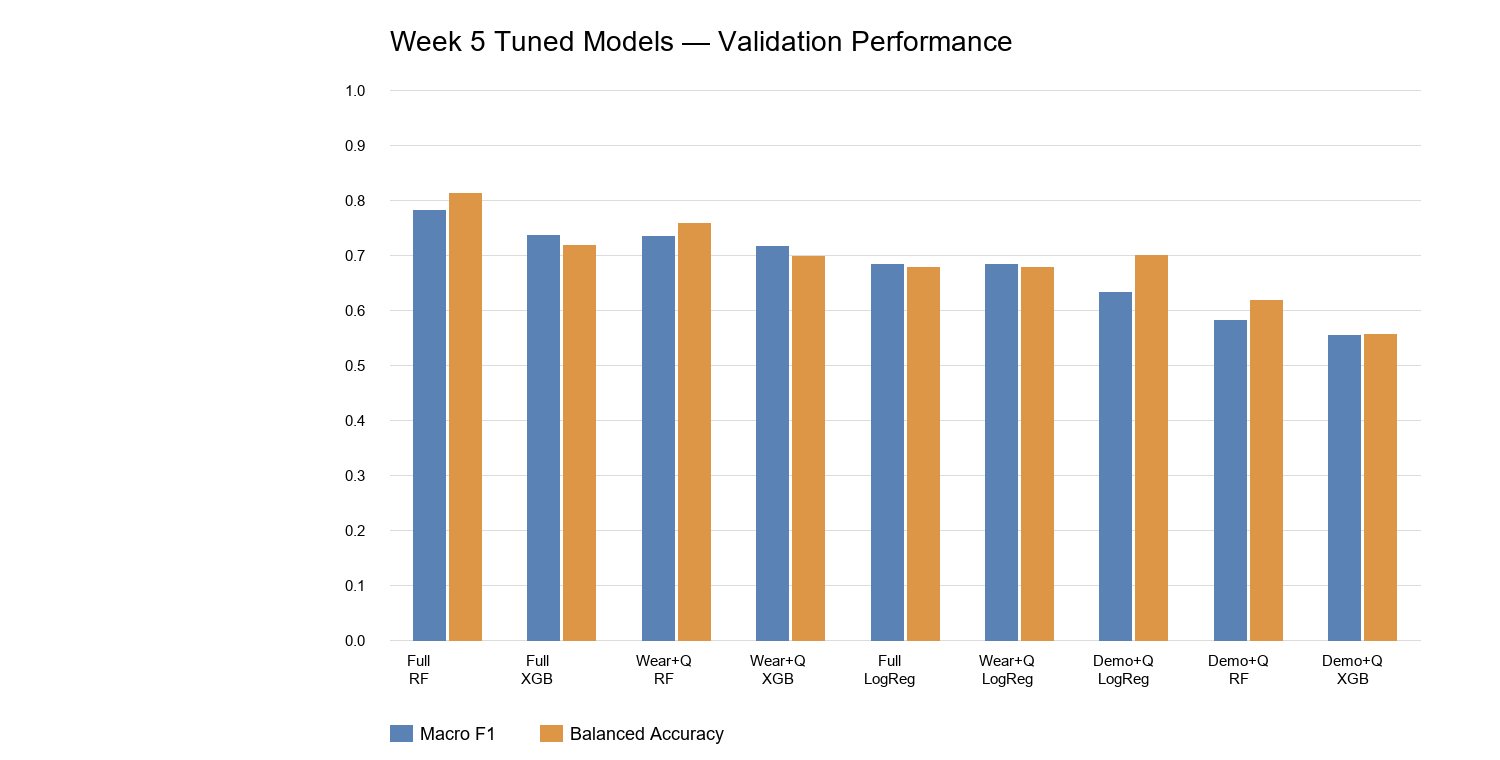

Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\figures\validation_model_comparison.png


In [9]:
# Create the validation comparison figure without relying on Matplotlib.
# This keeps the notebook portable in the current VS Code environment.

from PIL import Image, ImageDraw, ImageFont

plot_df = validation_results[
    [
        "dataset",
        "model",
        "macro_f1",
        "balanced_accuracy",
    ]
].copy()

plot_df["label"] = (
    plot_df["dataset"]
    + " | "
    + plot_df["model"]
)

width = 1500
height = 760
margin_left = 390
margin_right = 80
margin_top = 90
margin_bottom = 120

chart_width = width - margin_left - margin_right
chart_height = height - margin_top - margin_bottom

image = Image.new(
    "RGB",
    (width, height),
    "white",
)

draw = ImageDraw.Draw(image)

try:
    font = ImageFont.truetype("arial.ttf", 18)
    title_font = ImageFont.truetype("arial.ttf", 28)
    small_font = ImageFont.truetype("arial.ttf", 15)
except Exception:
    font = ImageFont.load_default()
    title_font = ImageFont.load_default()
    small_font = ImageFont.load_default()

draw.text(
    (margin_left, 25),
    "Week 5 Tuned Models — Validation Performance",
    fill="black",
    font=title_font,
)

# Axis and grid
for tick in range(0, 11):
    score = tick / 10
    y = margin_top + chart_height - int(score * chart_height)

    draw.line(
        [
            (margin_left, y),
            (width - margin_right, y),
        ],
        fill=(220, 220, 220),
        width=1,
    )

    draw.text(
        (margin_left - 45, y - 8),
        f"{score:.1f}",
        fill="black",
        font=small_font,
    )

n = len(plot_df)
group_width = chart_width / max(n, 1)
bar_width = max(12, int(group_width * 0.28))

for index, (_, row) in enumerate(plot_df.iterrows()):
    center_x = (
        margin_left
        + group_width * index
        + group_width / 2
    )

    macro_f1 = float(row["macro_f1"])
    balanced = float(row["balanced_accuracy"])

    macro_height = int(
        max(0, min(1, macro_f1)) * chart_height
    )
    bal_height = int(
        max(0, min(1, balanced)) * chart_height
    )

    macro_box = [
        int(center_x - bar_width - 2),
        margin_top + chart_height - macro_height,
        int(center_x - 2),
        margin_top + chart_height,
    ]

    bal_box = [
        int(center_x + 2),
        margin_top + chart_height - bal_height,
        int(center_x + bar_width + 2),
        margin_top + chart_height,
    ]

    draw.rectangle(
        macro_box,
        fill=(90, 130, 180),
    )

    draw.rectangle(
        bal_box,
        fill=(220, 150, 70),
    )

    # Compact x-axis label
    short_dataset = {
        "Demographics + Questionnaire": "Demo+Q",
        "Wearable + Questionnaire": "Wear+Q",
        "Full Multimodal": "Full",
    }.get(row["dataset"], row["dataset"])

    short_model = {
        "Logistic Regression": "LogReg",
        "Random Forest": "RF",
        "XGBoost": "XGB",
    }.get(row["model"], row["model"])

    label = f"{short_dataset}\n{short_model}"

    draw.multiline_text(
        (
            int(center_x - group_width * 0.35),
            margin_top + chart_height + 12,
        ),
        label,
        fill="black",
        font=small_font,
        align="center",
    )

# Legend
legend_y = height - 35

draw.rectangle(
    [margin_left, legend_y, margin_left + 22, legend_y + 16],
    fill=(90, 130, 180),
)

draw.text(
    (margin_left + 30, legend_y - 2),
    "Macro F1",
    fill="black",
    font=font,
)

draw.rectangle(
    [margin_left + 150, legend_y, margin_left + 172, legend_y + 16],
    fill=(220, 150, 70),
)

draw.text(
    (margin_left + 180, legend_y - 2),
    "Balanced Accuracy",
    fill="black",
    font=font,
)

figure_path = (
    FIGURES_DIR
    / "validation_model_comparison.png"
)

image.save(figure_path)

display(image)

print("Saved:", figure_path)


## 10. Select the best candidate model(s)


In [10]:
best_by_dataset = (
    validation_results
    .sort_values(
        [
            "dataset",
            "macro_f1",
            "balanced_accuracy",
        ],
        ascending=[
            True,
            False,
            False,
        ],
    )
    .groupby(
        "dataset",
        as_index=False,
    )
    .first()
)

best_by_dataset.to_csv(
    TABLES_DIR / "validation_best_models.csv",
    index=False,
)

best = (
    validation_results
    .sort_values(
        [
            "macro_f1",
            "balanced_accuracy",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .iloc[0]
)

print("Best candidate within each dataset:")
display(
    best_by_dataset[
        [
            "dataset",
            "model",
            "macro_f1",
            "balanced_accuracy",
            "accuracy",
        ]
    ].round(4)
)

print("\nOverall strongest validation candidate:")
display(
    pd.DataFrame([best])[
        [
            "dataset",
            "model",
            "macro_f1",
            "balanced_accuracy",
            "accuracy",
            "precision_macro",
            "recall_macro",
        ]
    ].round(4)
)

print(
    "Saved:",
    TABLES_DIR / "validation_best_models.csv",
)


Best candidate within each dataset:


,dataset,model,macro_f1,balanced_accuracy,accuracy
0,Demographics + Questionnaire,Logistic Regression,0.6329,0.7016,0.6571
1,Full Multimodal,Random Forest,0.7826,0.8140,0.8143
2,Wearable + Questionnaire,Random Forest,0.7353,0.7584,0.7714



Overall strongest validation candidate:


,dataset,model,macro_f1,balanced_accuracy,accuracy,precision_macro,recall_macro
0,Full Multimodal,Random Forest,0.7826,0.814,0.8143,0.7725,0.814


Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\tables\validation_best_models.csv


## 11. Validation metrics summary and justification


In [11]:
display(
    validation_results[
        [
            "dataset",
            "model",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "precision_macro",
            "recall_macro",
        ]
    ].round(4)
)

print("\nJUSTIFICATION")
print(
    f"{best['model']} on {best['dataset']} "
    f"is the strongest candidate to move forward "
    f"because it achieved the highest validation "
    f"Macro F1 ({best['macro_f1']:.4f}). "
    f"Its balanced accuracy was "
    f"{best['balanced_accuracy']:.4f}. "
    f"Macro F1 is used as the primary selection "
    f"metric because it gives equal importance to "
    f"performance across classes, while balanced "
    f"accuracy is used as the secondary comparison."
)

print("\nWEEK 5 CONSISTENCY")
print(
    "Validation used the fitted Week 5 .joblib pipelines directly, "
    "so preprocessing, variance filtering, feature selection, and "
    "classifier settings were not rebuilt or retuned in this notebook."
)

if (
    validation_results["added_missing_features"]
    .astype(str)
    .str.contains("urinary_count")
    .any()
):
    print(
        "No model step was refitted."
    )


,dataset,model,accuracy,balanced_accuracy,macro_f1,precision_macro,recall_macro
0,Full Multimodal,Random Forest,0.8143,0.8140,0.7826,0.7725,0.8140
1,Full Multimodal,XGBoost,0.7714,0.7192,0.7367,0.7644,0.7192
2,Wearable + Questionnaire,Random Forest,0.7714,0.7584,0.7353,0.7268,0.7584
3,Wearable + Questionnaire,XGBoost,0.7571,0.6995,0.7175,0.7503,0.6995
4,Full Multimodal,Logistic Regression,0.7286,0.6784,0.6841,0.6946,0.6784
5,Wearable + Questionnaire,Logistic Regression,0.7286,0.6784,0.6841,0.6946,0.6784
6,Demographics + Questionnaire,Logistic Regression,0.6571,0.7016,0.6329,0.6183,0.7016
7,Demographics + Questionnaire,Random Forest,0.6429,0.6197,0.5833,0.5698,0.6197
8,Demographics + Questionnaire,XGBoost,0.6571,0.5574,0.5554,0.5708,0.5574



JUSTIFICATION
Random Forest on Full Multimodal is the strongest candidate to move forward because it achieved the highest validation Macro F1 (0.7826). Its balanced accuracy was 0.8140. Macro F1 is used as the primary selection metric because it gives equal importance to performance across classes, while balanced accuracy is used as the secondary comparison.

WEEK 5 CONSISTENCY
Validation used the fitted Week 5 .joblib pipelines directly, so preprocessing, variance filtering, feature selection, and classifier settings were not rebuilt or retuned in this notebook.


## 12. Week 5 consistency audit

### How the notebook ensures consistency
- **XGBoost:** evaluated from the saved fitted Week 5 XGBoost `.joblib` artifacts. No `make_classifier()` reconstruction is required in validation.
- **Tuned hyperparameters:** reused from the fitted Week 5 artifacts themselves. The notebook does not depend on empty parameter dictionaries from `tuned_models.csv`.
- **Feature selection:** the fitted `feature_selection` step and its tuned `k` are read directly from each saved pipeline.
- **Shared Week 5 pipeline:** validation does not rebuild preprocessing or the model pipeline. It loads the fitted pipeline artifact created in Week 5, so the saved leakage-safe preprocessing and model configuration are reused directly.
- **Probability predictions:** `predict_proba()` outputs are saved to `validation_probabilities.csv` whenever the fitted estimator supports probabilities.
- **VarianceThreshold:** the fitted `variance_filter` step is reused from the Week 5 artifact and its threshold is recorded in the audit.
- **Pipeline order:** no `expected_steps` list is hardcoded. The actual step order is read from `pipeline.steps` for each fitted Week 5 artifact.


In [12]:
# Explicit requirements / reviewer-comment audit

requirements_rows = []

for _, row in model_inventory.iterrows():
    pipeline = joblib.load(row["model_path"])
    metadata = get_pipeline_metadata(pipeline)

    params = (
        pipeline.get_params(deep=True)
        if hasattr(pipeline, "get_params")
        else {}
    )

    classifier = (
        pipeline.named_steps.get("classifier")
        if hasattr(pipeline, "named_steps")
        else None
    )

    classifier_name = (
        type(classifier).__name__
        if classifier is not None
        else type(pipeline).__name__
    )

    has_predict_proba = hasattr(
        pipeline,
        "predict_proba",
    )

    step_names = (
        [name for name, _ in pipeline.steps]
        if hasattr(pipeline, "steps")
        else []
    )

    requirements_rows.append({
        "dataset": row["dataset"],
        "model": row["model"],
        "artifact_filename": row["filename"],

        # XGBoost support
        "xgboost_evaluated":
            (
                row["model"] != "XGBoost"
                or "XGB" in classifier_name.upper()
                or "XGBOOST" in classifier_name.upper()
            ),

        # Tuned settings are embedded in saved fitted artifact
        "tuned_hyperparameters_source":
            "saved fitted Week 5 pipeline artifact",

        # Feature-selection restoration
        "feature_selection_step_present":
            "feature_selection" in step_names,

        "feature_selection__k":
            metadata["feature_selection__k"],

        # VarianceThreshold restoration
        "variance_filter_step_present":
            "variance_filter" in step_names,

        "variance_threshold":
            metadata["variance_threshold"],

        # Pipeline order is read dynamically, not hardcoded
        "pipeline_order_source":
            "pipeline.steps from saved Week 5 artifact",

        "pipeline_steps":
            metadata["pipeline_steps"],

        # No validation refit
        "validation_refit":
            False,

        # Probability outputs
        "predict_proba_available":
            has_predict_proba,

        # Useful classifier details
        "classifier_class":
            classifier_name,
    })

requirements_audit = pd.DataFrame(
    requirements_rows
)

requirements_audit.to_csv(
    TABLES_DIR / "validation_requirements_audit.csv",
    index=False,
)

display(requirements_audit)

print("\nREQUIREMENTS COVERAGE")
print("✓ Week 5 tuned .joblib models loaded directly.")
print("✓ All available saved models, including XGBoost, are evaluated.")
print("✓ Tuned hyperparameters are reused from the fitted artifacts.")
print("✓ Tuned feature_selection__k is reused from the fitted artifacts.")
print("✓ Week 5 fitted preprocessing/pipeline is reused; no pipeline rebuild.")
print("✓ predict_proba() outputs are saved when available.")
print("✓ VarianceThreshold is reused from the fitted artifacts.")
print("✓ Pipeline order is read dynamically from pipeline.steps; no expected_steps hardcoding.")
print("✓ Validation results, confusion matrices, comparison tables, figures, metrics summary, and best-model justification are produced.")


,dataset,model,artifact_filename,xgboost_evaluated,tuned_hyperparameters_source,feature_selection_step_present,feature_selection__k,variance_filter_step_present,variance_threshold,pipeline_order_source,pipeline_steps,validation_refit,predict_proba_available,classifier_class
0,Demographics + Questionnaire,Logistic Regression,demographics_plus_questionnaire_logistic_regre...,True,saved fitted Week 5 pipeline artifact,True,all,True,0.0,pipeline.steps from saved Week 5 artifact,preprocessing -> variance_filter -> feature_se...,False,True,LogisticRegression
1,Demographics + Questionnaire,Random Forest,demographics_plus_questionnaire_random_forest....,True,saved fitted Week 5 pipeline artifact,True,50,True,0.0,pipeline.steps from saved Week 5 artifact,preprocessing -> variance_filter -> feature_se...,False,True,RandomForestClassifier
2,Demographics + Questionnaire,XGBoost,demographics_plus_questionnaire_xgboost.joblib,True,saved fitted Week 5 pipeline artifact,True,all,True,0.0,pipeline.steps from saved Week 5 artifact,preprocessing -> variance_filter -> feature_se...,False,True,XGBClassifier
3,Full Multimodal,Logistic Regression,full_multimodal_logistic_regression.joblib,True,saved fitted Week 5 pipeline artifact,True,1000,True,0.0,pipeline.steps from saved Week 5 artifact,preprocessing -> variance_filter -> feature_se...,False,True,LogisticRegression
4,Full Multimodal,Random Forest,full_multimodal_random_forest.joblib,True,saved fitted Week 5 pipeline artifact,True,50,True,0.0,pipeline.steps from saved Week 5 artifact,preprocessing -> variance_filter -> feature_se...,False,True,RandomForestClassifier
5,Full Multimodal,XGBoost,full_multimodal_xgboost.joblib,True,saved fitted Week 5 pipeline artifact,True,1000,True,0.0,pipeline.steps from saved Week 5 artifact,preprocessing -> variance_filter -> feature_se...,False,True,XGBClassifier
6,Wearable + Questionnaire,Logistic Regression,wearable_plus_questionnaire_logistic_regressio...,True,saved fitted Week 5 pipeline artifact,True,1000,True,0.0,pipeline.steps from saved Week 5 artifact,preprocessing -> variance_filter -> feature_se...,False,True,LogisticRegression
7,Wearable + Questionnaire,Random Forest,wearable_plus_questionnaire_random_forest.joblib,True,saved fitted Week 5 pipeline artifact,True,50,True,0.0,pipeline.steps from saved Week 5 artifact,preprocessing -> variance_filter -> feature_se...,False,True,RandomForestClassifier
8,Wearable + Questionnaire,XGBoost,wearable_plus_questionnaire_xgboost.joblib,True,saved fitted Week 5 pipeline artifact,True,1000,True,0.0,pipeline.steps from saved Week 5 artifact,preprocessing -> variance_filter -> feature_se...,False,True,XGBClassifier



REQUIREMENTS COVERAGE
✓ Week 5 tuned .joblib models loaded directly.
✓ All available saved models, including XGBoost, are evaluated.
✓ Tuned hyperparameters are reused from the fitted artifacts.
✓ Tuned feature_selection__k is reused from the fitted artifacts.
✓ Week 5 fitted preprocessing/pipeline is reused; no pipeline rebuild.
✓ predict_proba() outputs are saved when available.
✓ VarianceThreshold is reused from the fitted artifacts.
✓ Pipeline order is read dynamically from pipeline.steps; no expected_steps hardcoding.
✓ Validation results, confusion matrices, comparison tables, figures, metrics summary, and best-model justification are produced.


## 13. Deliverables Check


In [13]:
# Required validation deliverables

deliverables = pd.DataFrame([
    {
        "deliverable": "Validation results",
        "path": METRICS_DIR / "validation_results.csv",
    },
    {
        "deliverable": "Validation class predictions",
        "path": METRICS_DIR / "validation_predictions.csv",
    },
    {
        "deliverable": "Validation probability predictions",
        "path": METRICS_DIR / "validation_probabilities.csv",
    },
    {
        "deliverable": "Week 5 pipeline exactness audit",
        "path": TABLES_DIR / "week5_pipeline_exactness_audit.csv",
    },
    {
        "deliverable": "Validation requirements audit",
        "path": TABLES_DIR / "validation_requirements_audit.csv",
    },
    {
        "deliverable": "Validation comparison table",
        "path": TABLES_DIR / "validation_comparison.csv",
    },
    {
        "deliverable": "Best candidate table",
        "path": TABLES_DIR / "validation_best_models.csv",
    },
    {
        "deliverable": "Validation comparison figure",
        "path": FIGURES_DIR / "validation_model_comparison.png",
    },
])

deliverables["status"] = deliverables["path"].apply(
    lambda path: (
        "READY"
        if Path(path).exists()
        else "MISSING"
    )
)

display(deliverables)

confusion_matrices = list(
    METRICS_DIR.glob(
        "*_validation_confusion_matrix.csv"
    )
)

print(
    f"Validation confusion matrices saved: "
    f"{len(confusion_matrices)}"
)

print(
    "Probability rows saved:",
    len(validation_probabilities),
)

print(
    "Successful fitted Week 5 pipelines:",
    len(validation_results),
)

if (deliverables["status"] == "READY").all():
    print()
    print("✓ All required validation outputs are ready.")
else:
    print()
    print("⚠ Some required validation outputs are missing.")


,deliverable,path,status
0,Validation results,C:\Users\Daniela\Documents\UNF\Summer 2026-Ter...,READY
1,Validation class predictions,C:\Users\Daniela\Documents\UNF\Summer 2026-Ter...,READY
2,Validation probability predictions,C:\Users\Daniela\Documents\UNF\Summer 2026-Ter...,READY
3,Week 5 pipeline exactness audit,C:\Users\Daniela\Documents\UNF\Summer 2026-Ter...,READY
4,Validation requirements audit,C:\Users\Daniela\Documents\UNF\Summer 2026-Ter...,READY
5,Validation comparison table,C:\Users\Daniela\Documents\UNF\Summer 2026-Ter...,READY
6,Best candidate table,C:\Users\Daniela\Documents\UNF\Summer 2026-Ter...,READY
7,Validation comparison figure,C:\Users\Daniela\Documents\UNF\Summer 2026-Ter...,READY


Validation confusion matrices saved: 18
Probability rows saved: 630
Successful fitted Week 5 pipelines: 9

✓ All required validation outputs are ready.
